# Proyek Klasifikasi Gambar: Rice dataset
- **Nama:** Muhammad Rafif Pasya
- **Email:** Rafiffiko18@gmail.com
- **ID Dicoding:** Muhammad Rafif Pasya


## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install kagglehub tensorflowjs

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import tensorflow as tf
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import os
import subprocess
import kagglehub
import shutil
import random
from tensorflow.keras.preprocessing import image

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [4]:
!pip install pipreqs
!python -m pipreqs.pipreqs . --force --scan-notebooks

Defaulting to user installation because normal site-packages is not writeable


Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in .\requirements.txt


## Data Preparation

### Data Loading

In [3]:
destination_path = './rice-dataset'
source_dataset_path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")
print(f"Dataset berhasil diunduh. {destination_path}...")
if os.path.exists(os.path.join(source_dataset_path, 'Rice_Image_Dataset')):
    source_dataset_path = os.path.join(source_dataset_path, 'Rice_Image_Dataset')

os.makedirs(destination_path, exist_ok=True)
classes = [d for d in os.listdir(source_dataset_path) if os.path.isdir(os.path.join(source_dataset_path, d))]

for class_name in classes:
    source_class_dir = os.path.join(source_dataset_path, class_name)
    dest_class_dir = os.path.join(destination_path, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    images = [f for f in os.listdir(source_class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    images_to_copy = images[:300]

    for img in images_to_copy:
        src_file = os.path.join(source_class_dir, img)
        dst_file = os.path.join(dest_class_dir, img)
        if not os.path.exists(dst_file):
            shutil.copy2(src_file, dst_file)

dataset_path = destination_path
data_dir = pathlib.Path(dataset_path)

image_count = len(list(data_dir.rglob('*.jpg')) + list(data_dir.rglob('*.jpeg')) + list(data_dir.rglob('*.png')))
print(f"\nTotal gambar  : {image_count}")

Dataset berhasil diunduh. ./rice-dataset...

Total gambar  : 1500


 Distribusi Data 
Kelas 'Jasmine': 300 gambar
Kelas 'Ipsala': 300 gambar
Kelas 'Basmati': 300 gambar
Kelas 'Arborio': 300 gambar
Kelas 'Karacadag': 300 gambar


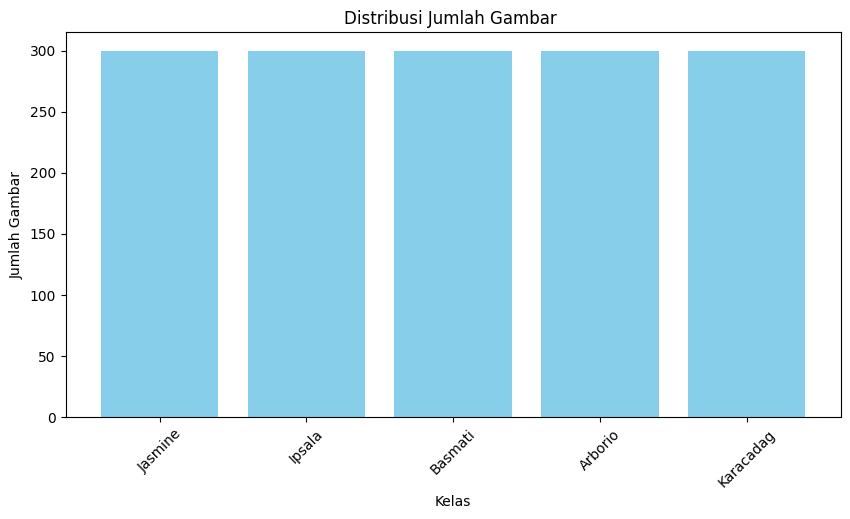

In [38]:
print(" Distribusi Data ")
classes = os.listdir(data_dir)
class_counts = []

for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)
    if os.path.isdir(class_dir):
        count = len(os.listdir(class_dir))
        class_counts.append(count)
        print(f"Kelas '{class_name}': {count} gambar")

plt.figure(figsize=(10, 5))
plt.bar(classes, class_counts, color='skyblue')
plt.title('Distribusi Jumlah Gambar ')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45)
plt.show()


 Sampel Gambar 


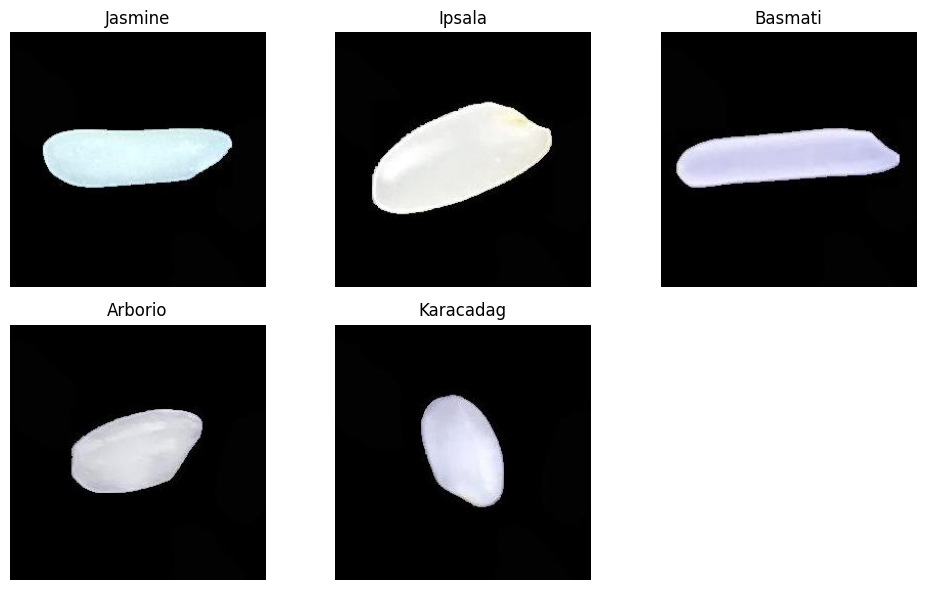

In [39]:
print("\n Sampel Gambar ")
plt.figure(figsize=(10, 6))

for i, class_name in enumerate(classes[:5]):
    class_dir = os.path.join(data_dir, class_name);
    if os.path.isdir(class_dir):
        sample_image = os.listdir(class_dir)[0]
        img_path = os.path.join(class_dir, sample_image)

        img = mpimg.imread(img_path)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

### Data Preprocessing

In [40]:
batch_size = 32
img_height = 150
img_width = 150

print(f"Ukuran Batch: {batch_size}")
print(f"Target Resolusi Gambar: {img_height}x{img_width}")

Ukuran Batch: 32
Target Resolusi Gambar: 150x150


#### Split Dataset

In [41]:
batch_size = 32
img_height = 150
img_width = 150

print("Membagi Dataset")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_and_test_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"\nKelas yang ditemukan: {class_names}")

val_batches = tf.data.experimental.cardinality(val_and_test_ds)
val_ds = val_and_test_ds.take(val_batches // 2)
test_ds = val_and_test_ds.skip(val_batches // 2)

print(f"\nDistribusi Batch Akhir:")
print(f"- Jumlah batch Training: {tf.data.experimental.cardinality(train_ds)}")
print(f"- Jumlah batch Validation: {tf.data.experimental.cardinality(val_ds)}")
print(f"- Jumlah batch Testing: {tf.data.experimental.cardinality(test_ds)}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Membagi Dataset
Found 1500 files belonging to 5 classes.
Using 1200 files for training.
Found 1500 files belonging to 5 classes.
Using 300 files for validation.

Kelas yang ditemukan: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

Distribusi Batch Akhir:
- Jumlah batch Training: 38
- Jumlah batch Validation: 5
- Jumlah batch Testing: 5


## Modelling

In [42]:
class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') >= 0.95 and logs.get('val_accuracy') >= 0.95):
            print("\nTarget akurasi >= 95% tercapai! Menghentikan proses training.")
            self.model.stop_training = True

# 1. Inisialisasi Custom Callback
target_cb = TargetCallback()

# 2. Inisialisasi Early Stopping
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Memantau nilai validation loss
    patience=10,                # Toleransi 10 epoch jika tidak ada perbaikan sebelum dihentikan
    restore_best_weights=True   # Secara otomatis mengembalikan bobot model terbaik
)

data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
])

model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  data_augmentation,
  tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

epochs = 100

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  # 3. Masukkan kedua callback ke dalam array parameter callbacks
  callbacks=[target_cb, early_stopper]
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.5933 - loss: 0.9703 - val_accuracy: 0.8687 - val_loss: 0.3238
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7933 - loss: 0.5197 - val_accuracy: 0.8188 - val_loss: 0.3780
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8375 - loss: 0.4054 - val_accuracy: 0.8438 - val_loss: 0.3986
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8292 - loss: 0.4195 - val_accuracy: 0.8813 - val_loss: 0.3278
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8667 - loss: 0.3393 - val_accuracy: 0.8562 - val_loss: 0.3450
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8667 - loss: 0.3287 - val_accuracy: 0.8938 - val_loss: 0.2783
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8783 - loss: 0.3260 - val_accuracy: 0.9250 - val_loss: 0.2551
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8775 - loss: 0.3023 - val_accuracy: 0.8938 - val_l

## Evaluasi dan Visualisasi

Evaluasi Model Test Set 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9286 - loss: 0.2114
Test Accuracy: 92.86%



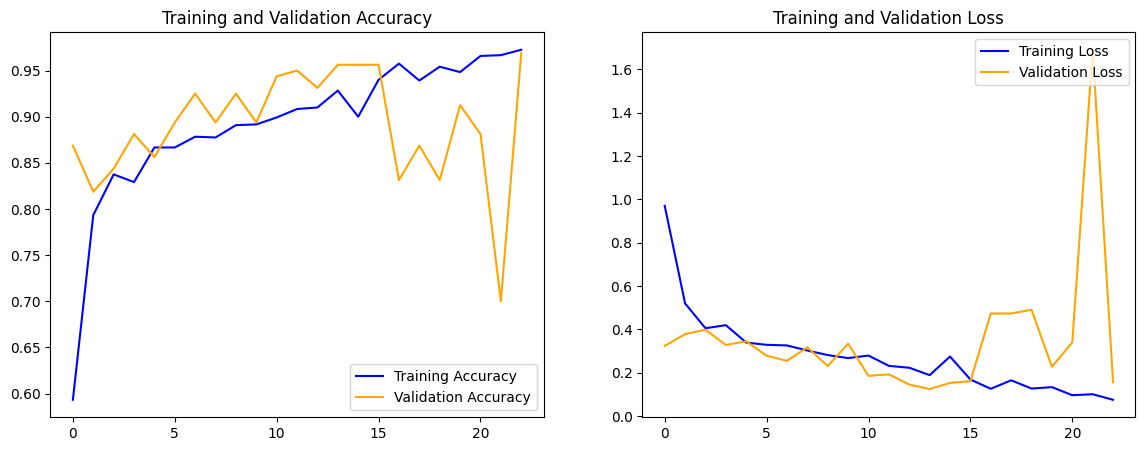

In [43]:
print("Evaluasi Model Test Set ")
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Konversi Model

In [44]:
os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite', exist_ok=True)
os.makedirs('submission/tfjs_model', exist_ok=True)

inference_model = tf.keras.Sequential([
    model.layers[0]
] + model.layers[2:])

inference_model.build(input_shape=(None, img_height, img_width, 3))

saved_model_path = 'submission/saved_model'
inference_model.export(saved_model_path)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

with open('submission/tflite/label.txt', 'w') as f:
    f.write('\n'.join(class_names))

subprocess.run(['tensorflowjs_converter', '--input_format=tf_saved_model', saved_model_path, 'submission/tfjs_model'])

print("Model  dikonversi disimpan di folder 'submission/'")

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_184')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136189746738576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746733200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189749898384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746728208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746739536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746740496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746727056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746740112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746741072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746738384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1361

In [45]:
!zip -r submission.zip submission

updating: submission/ (stored 0%)
updating: submission/tfjs_model/ (stored 0%)
updating: submission/tfjs_model/group1-shard2of6.bin (deflated 8%)
updating: submission/tfjs_model/group1-shard3of6.bin (deflated 7%)
updating: submission/tfjs_model/group1-shard1of6.bin (deflated 8%)
updating: submission/tfjs_model/group1-shard6of6.bin (deflated 8%)
updating: submission/tfjs_model/model.json (deflated 90%)
updating: submission/tfjs_model/group1-shard4of6.bin (deflated 7%)
updating: submission/tfjs_model/group1-shard5of6.bin (deflated 8%)
updating: submission/tflite/ (stored 0%)
updating: submission/tflite/model.tflite (deflated 8%)
updating: submission/tflite/label.txt (stored 0%)
updating: submission/saved_model/ (stored 0%)
updating: submission/saved_model/fingerprint.pb (stored 0%)
updating: submission/saved_model/saved_model.pb (deflated 86%)
updating: submission/saved_model/variables/ (stored 0%)
updating: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
upd

## Inference (Optional)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


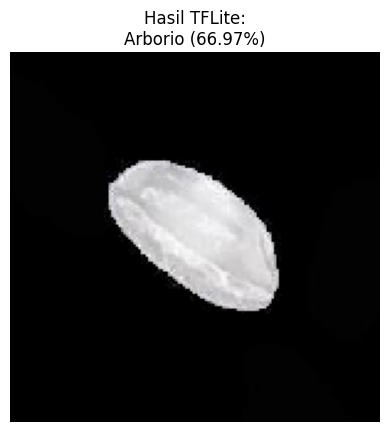

In [46]:

interpreter = tf.lite.Interpreter(model_path="submission/tflite/model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Ambil 1 gambar acak
all_image_paths = list(data_dir.rglob('*.jpg')) + list(data_dir.rglob('*.jpeg')) + list(data_dir.rglob('*.png'))
test_image_path = random.choice(all_image_paths)

img = image.load_img(test_image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

predicted_class_idx = np.argmax(output_data[0])
confidence = np.max(output_data[0]) * 100

plt.imshow(img)
plt.axis('off')
plt.title(f"Hasil TFLite:\n{class_names[predicted_class_idx]} ({confidence:.2f}%)")
plt.show()